Завантажуємо бібліотеки

In [106]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.axes3d import Axes3D
from sklearn.datasets import fetch_openml
from sklearn.decomposition import PCA
from sklearn.metrics import mean_squared_error

1. Завантажуємо дані з MNIST. Виводимо кількість зображень, міток тк класів

In [107]:
x, y = fetch_openml("mnist_784", version=1, return_X_y = True, as_frame = False)
y_int = y.astype(int)

print(f"Зображень та міток(пікселів): {x.shape}. класів: {len(np.unique(y))}")

Зображень та міток(пікселів): (70000, 784). класів: 10


Генеруємо 10 випадкових індексів від 0 до 69999(x.shape[0]), беремо за ними картинки та робимо їх √784(x.shape[1]) на √784(x.shape[1]), виводимо на полотні (1 рядок, 10 колонок)

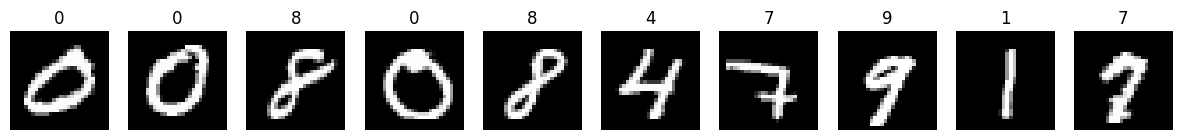

In [109]:
indexes = np.random.randint(0, x.shape[0], size = 10)
figure, pics = plt.subplots(1, 10, figsize = (15, 5))

for i, n in enumerate(indexes):
    pics[i].imshow(x[n].reshape(int(np.sqrt(x.shape[1])), int(np.sqrt(x.shape[1]))), cmap = "gray")
    pics[i].set_title(y_int[n])
    pics[i].axis('off')
plt.show()

2PRINCIPLE COMPONENT ANALYSIS (PCA) - Метод Головних Компонент. Метод зменшення розмірності, що знаходить напрямки максимальної дисперсії даних та проєктує дані на ці напрямки. Зберігаємо 3 компоненти з 784. Виводимо відсоток поясненої дисперсії для кожного напрямку та сумарну пояснену дисперсію

In [105]:
pca = PCA(n_components = 3)
x_pca = pca.fit_transform(x)
print(f"Після PCA x має розмірність: {x_pca.shape}")

print(f"\nВідсоток поясненої дисперсії для кожної компоненти:")
for i, ratio in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i + 1} ratio: {ratio} ({ratio * 100:}%)")

print(f"\nСумарна пояснена дисперсія: {sum(pca.explained_variance_ratio_) * 100}%")

Після PCA x має розмірність: (70000, 3)

Відсоток поясненої дисперсії для кожної компоненти:
PC1 ratio: 0.09746115922494747 (9.746115922494747%)
PC2 ratio: 0.07155444586878702 (7.155444586878702%)
PC3 ratio: 0.06149530980723026 (6.149530980723026%)

Сумарна пояснена дисперсія: 23.05109149009647%


3. Візуалізуємо наші нові 3 компоненти у просторі

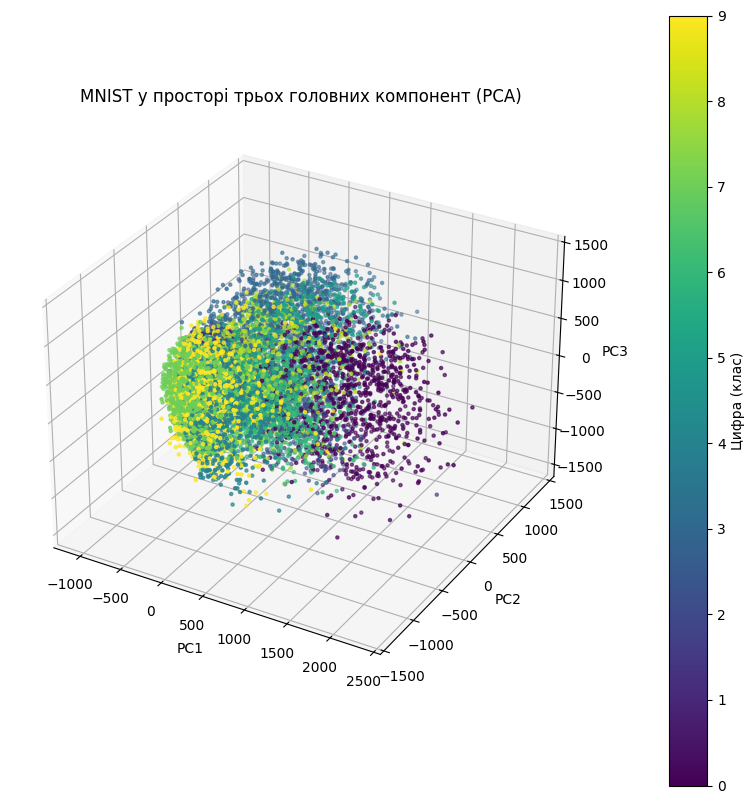

In [136]:
points = 10000
rng = np.random.default_rng(1)
idx = rng.choice(x_pca.shape[0], size = points, replace = False) #Беремо points різних рандомних точок від 0 до 69999. Сід фіксований, щоб результат був детермінованим

x_sub = x_pca[idx]
y_sub = y_int[idx]

PC1 = x_sub[:, 0]
PC2 = x_sub[:, 1]
PC3 = x_sub[:, 2]

figure = plt.figure(figsize = (10, 10))
ax = figure.add_subplot(111, projection = "3d")

sc = ax.scatter(PC1, PC2, PC3, c = y_sub, s = 5)

ax.set_title("MNIST у просторі трьох головних компонент (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

cbar = plt.colorbar(sc, ax = ax, pad = 0.1)
cbar.set_label("Цифра (клас)")

plt.show()